In [13]:
import illustris_python as il
from matplotlib import rcParams, pyplot as plt
import numpy as np

%matplotlib inline

In [38]:
rcParams['lines.markersize'] = 3
rcParams['axes.labelsize'] = 18
rcParams['errorbar.capsize'] = 2

In [2]:
basePath = '../sims.illustris/Illustris-1/output/'

### read in $\dot{M} \left[(10^{10}M_{\odot}/h) \, / \, (0.978Gyr/h)\right]$ values at $z=0.50, 1.04, 2.10, 3.08$


In [3]:
fields = ['SubhaloBHMdot']
z_dict = {103: 0.50, 84: 1.04, 67: 2.10, 59: 3.08}
mdots = {z: il.groupcat.loadSubhalos(basePath, snap, fields=fields) for snap, z in z_dict.items()}
mdots

{0.5: array([0.0003798 , 0.00479833, 0.00319049, ..., 0.        , 0.        ,
        0.        ], shape=(4715773,), dtype=float32),
 1.04: array([2.6808393e-03, 8.3487062e-04, 8.6823529e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00], shape=(5059097,), dtype=float32),
 2.1: array([1.08684385e-02, 1.05237756e-04, 8.69723372e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       shape=(5487307,), dtype=float32),
 3.08: array([0.00621275, 0.0301751 , 0.00678593, ..., 0.        , 0.        ,
        0.        ], shape=(5616703,), dtype=float32)}

In [4]:
mdots = {z: arr.astype(np.float64) for z, arr in mdots.items()}
mdots

{0.5: array([0.0003798 , 0.00479833, 0.00319049, ..., 0.        , 0.        ,
        0.        ], shape=(4715773,)),
 1.04: array([2.68083927e-03, 8.34870618e-04, 8.68235293e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(5059097,)),
 2.1: array([1.08684385e-02, 1.05237756e-04, 8.69723372e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(5487307,)),
 3.08: array([0.00621275, 0.0301751 , 0.00678593, ..., 0.        , 0.        ,
        0.        ], shape=(5616703,))}

### $L_{Bol}=\epsilon \dot{M}c^2$ [erg/s]
#### convert $\dot{M}$ to cgs units

In [5]:
def convert(mdot):
    """
    Convert mdot value from Illustris units to cgs
    """
    M_sun = 1.989e33  # [g]
    year = 3.154e7  # [s]
    return mdot * (10**10 / (0.978 * 10**9)) * M_sun/year

In [6]:
eff = 0.2  # quasar radiative efficiency
c = 2.998e10  # [cm/s]
Lbol = {z: eff * convert(arr) * c**2 for z, arr in mdots.items()}

In [7]:
Lbol

{0.5: array([4.40227336e+43, 5.56182314e+44, 3.69814840e+44, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(4715773,)),
 1.04: array([3.10740792e+44, 9.67713209e+43, 1.00638679e+43, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(5059097,)),
 2.1: array([1.25977981e+45, 1.21982932e+43, 1.00811165e+43, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(5487307,)),
 3.08: array([7.20130556e+44, 3.49764878e+45, 7.86568497e+44, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(5616703,))}

In [8]:
log_Lbol = {z: np.log10(arr[arr > 0]) for z, arr in Lbol.items()}

In [9]:
log_Lbol

{0.5: array([43.64367701, 44.74521717, 44.56798433, ..., 39.44875478,
        39.52851641, 37.33107796], shape=(31633,)),
 1.04: array([44.49239827, 43.98574667, 43.00276493, ..., 30.76350466,
        39.82866042, 39.66127877], shape=(30778,)),
 2.1: array([45.10029465, 43.08629907, 43.00350863, ..., 40.4564895 ,
        40.11666295, 38.8578896 ], shape=(24065,)),
 3.08: array([44.85741124, 45.5437762 , 44.89573655, ..., 40.24394615,
        39.52278009, 39.98387004], shape=(16289,))}

In [36]:
phi = {}
centers = {}
phi_err = {}
dlogL = 0.1

bins = np.arange(43, 50, dlogL)

for z, L in log_Lbol.items():
    N, edges = np.histogram(L, bins=bins)
    V = (106.5)**3  # Illustris-1 volume in Mpc^3
    phi_err[z] = np.sqrt(N) / (V * dlogL)
    phi[z] = N / (V * dlogL)
    centers[z] = 0.5 * (edges[1:] + edges[:-1])

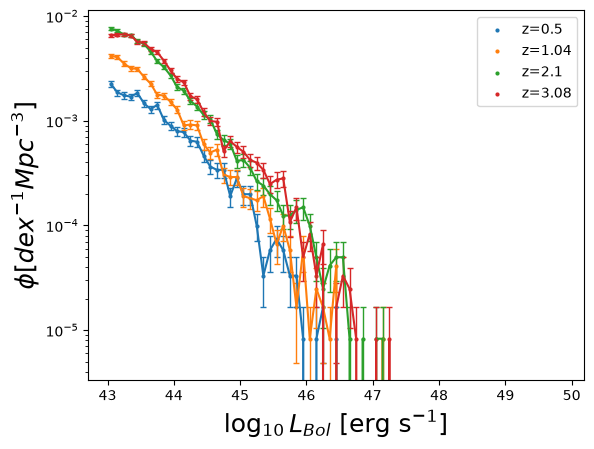

In [39]:
for z in log_Lbol:
    plt.scatter(centers[z], phi[z], label=f'{z=}', linewidths=0)
    plt.errorbar(centers[z], phi[z], yerr=phi_err[z], elinewidth=1)
plt.legend()
plt.xlabel(r'$\log_{10}L_{Bol}$ [erg s$^{-1}$]')
plt.ylabel(r'$ \phi [dex^{-1} Mpc^{-3}$]')
plt.yscale('log')
plt.show()